In [1]:
%pip install -q joblib scikit-learn pandas matplotlib numpy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ruta = Path("..")
datos = pd.read_csv(ruta / "data" / "comprar_alquilar.csv")
datos.head()

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1


In [3]:
print("Dimensiones:", datos.shape)
print("Valores nulos:", datos.isna().sum().sum())
print("Distribucion de la variable comprar (0=alquilar, 1=comprar):")
print(datos["comprar"].value_counts())
datos.describe()

Dimensiones: (202, 10)
Valores nulos: 0
Distribucion de la variable comprar (0=alquilar, 1=comprar):
comprar
0    135
1     67
Name: count, dtype: int64


,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
count,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000,202.000000
mean,4958.995050,971.584158,211.742574,515.425743,38749.668317,373349.638614,1.024752,1.232673,4.490099,0.331683
std,1682.862556,272.106351,124.940754,168.103075,17365.231870,136371.525622,0.837184,1.367833,2.535794,0.471988
min,2008.000000,384.000000,0.000000,201.000000,10319.000000,176553.000000,0.000000,0.000000,0.000000,0.000000
25%,3513.750000,766.750000,99.000000,383.250000,24964.250000,274810.000000,0.000000,0.000000,2.000000,0.000000
50%,4947.500000,968.000000,208.500000,522.500000,38523.000000,340783.500000,1.000000,1.000000,5.000000,0.000000
75%,6374.500000,1165.250000,318.750000,656.750000,52150.750000,444482.000000,2.000000,2.000000,7.000000,1.000000
max,7984.000000,1585.000000,448.000000,828.000000,69934.000000,669540.000000,2.000000,4.000000,8.000000,1.000000


In [4]:
BLUE = "#2a78d6"
ORANGE = "#eb6834"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
})

x = datos.drop(columns=["comprar"])
y = datos["comprar"]
print("Escalas muy distintas entre variables (ejemplo):")
print(x[["ingresos", "hijos"]].describe().loc[["mean", "std"]])

Escalas muy distintas entre variables (ejemplo):
         ingresos     hijos
mean  4958.995050  1.232673
std   1682.862556  1.367833


In [5]:
pca_sin_escalar = PCA(n_components=2, random_state=42)
componentes_sin_escalar = pca_sin_escalar.fit_transform(x)

escalador = StandardScaler()
x_escalado = escalador.fit_transform(x)
pca_con_escalar = PCA(n_components=2, random_state=42)
componentes_con_escalar = pca_con_escalar.fit_transform(x_escalado)

print("Varianza explicada SIN escalar (2 comp.):", np.round(pca_sin_escalar.explained_variance_ratio_, 3))
print("Varianza explicada CON escalar (2 comp.):", np.round(pca_con_escalar.explained_variance_ratio_, 3))

Varianza explicada SIN escalar (2 comp.): [0.99 0.01]
Varianza explicada CON escalar (2 comp.): [0.299 0.233]


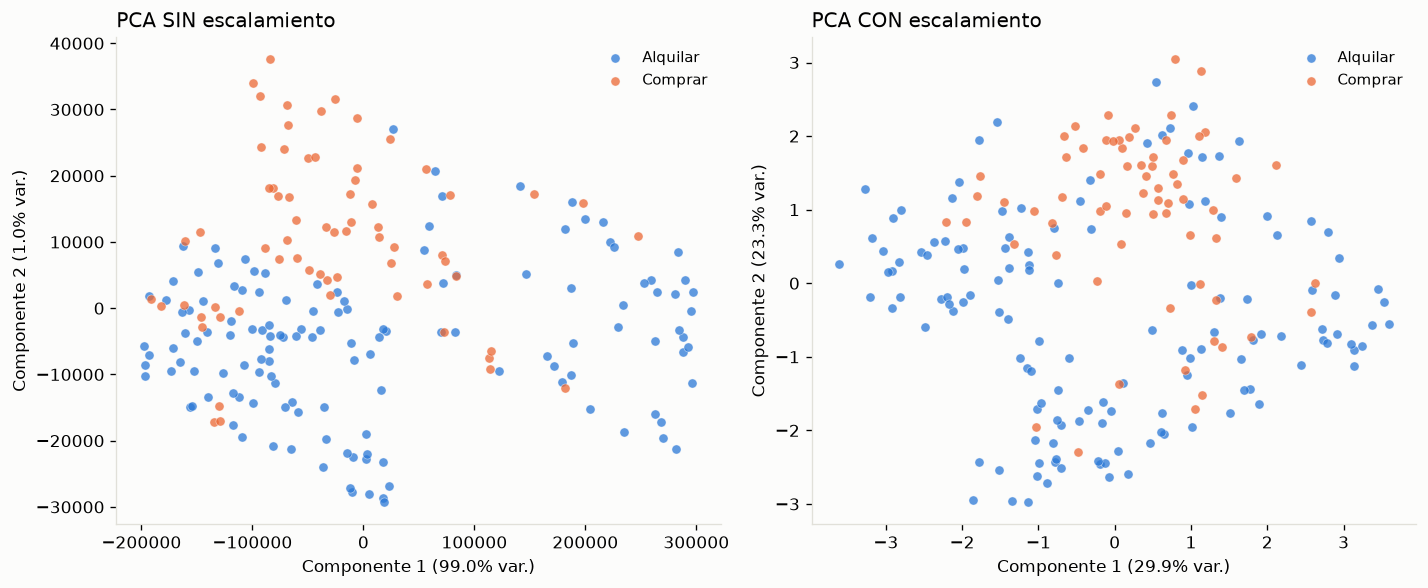

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

for ax, comp, titulo, varianza in [
    (ax1, componentes_sin_escalar, "PCA SIN escalamiento", pca_sin_escalar.explained_variance_ratio_),
    (ax2, componentes_con_escalar, "PCA CON escalamiento", pca_con_escalar.explained_variance_ratio_),
]:
    for etiqueta, color, nombre in [(0, BLUE, "Alquilar"), (1, ORANGE, "Comprar")]:
        mascara = y == etiqueta
        ax.scatter(comp[mascara, 0], comp[mascara, 1], s=30, alpha=0.75,
                   color=color, label=nombre, edgecolor="white", linewidth=0.3)
    ax.set_xlabel(f"Componente 1 ({varianza[0]*100:.1f}% var.)")
    ax.set_ylabel(f"Componente 2 ({varianza[1]*100:.1f}% var.)")
    ax.set_title(titulo, loc="left")
    ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig(ruta / "figures" / "sa_pca_comparacion.png", facecolor=SURFACE)
plt.show()

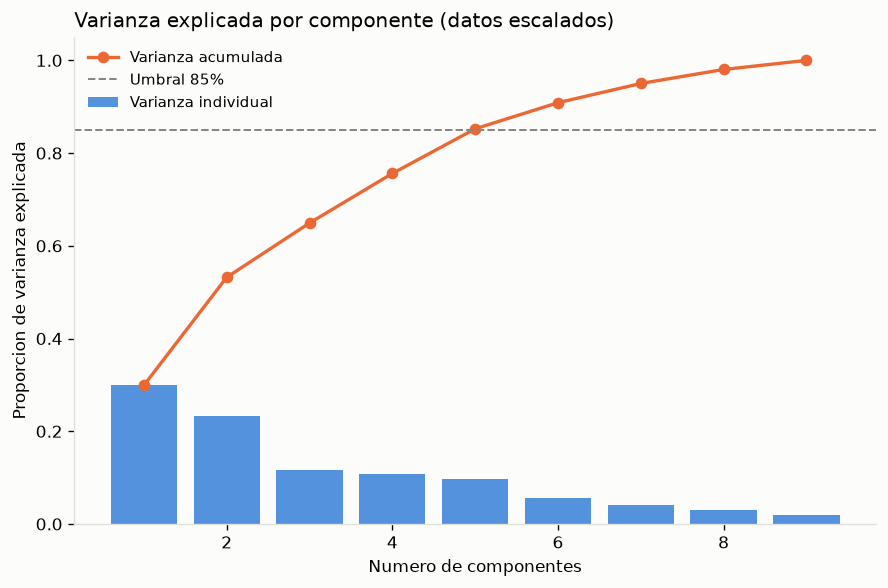

Varianza acumulada por componente: [0.299 0.532 0.649 0.756 0.852 0.909 0.95  0.98  1.   ]
Componentes necesarios para >=85% de varianza: 5


In [7]:
pca_completo = PCA(random_state=42)
pca_completo.fit(x_escalado)
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(7.5, 5), dpi=120)
ax.bar(range(1, len(varianza_acumulada) + 1), pca_completo.explained_variance_ratio_,
       color=BLUE, alpha=0.8, label="Varianza individual")
ax.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada,
        color=ORANGE, marker="o", linewidth=2, label="Varianza acumulada")
ax.axhline(0.85, color=MUTED, linestyle="--", linewidth=1.2, label="Umbral 85%")
ax.set_xlabel("Numero de componentes")
ax.set_ylabel("Proporcion de varianza explicada")
ax.set_title("Varianza explicada por componente (datos escalados)", loc="left")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(ruta / "figures" / "sa_pca_varianza.png", facecolor=SURFACE)
plt.show()

n_componentes = int(np.argmax(varianza_acumulada >= 0.85) + 1)
print("Varianza acumulada por componente:", np.round(varianza_acumulada, 3))
print(f"Componentes necesarios para >=85% de varianza: {n_componentes}")

In [8]:
pca_final = PCA(n_components=n_componentes, random_state=42)
componentes_final = pca_final.fit_transform(x_escalado)
print(f"Reduccion de dimensionalidad: {x.shape[1]} variables originales -> {n_componentes} componentes")
print(f"Varianza total conservada: {pca_final.explained_variance_ratio_.sum()*100:.1f}%")

joblib.dump(
    {"modelo": pca_final, "escalador": escalador, "columnas": list(x.columns), "n_componentes": n_componentes},
    ruta / "models" / "sa_pca_comprar_alquilar.joblib"
)
print("Modelo guardado en la carpeta models/")

Reduccion de dimensionalidad: 9 variables originales -> 5 componentes
Varianza total conservada: 85.2%
Modelo guardado en la carpeta models/
